# The MINT benchmark forward detector

Geometry and composition of the benchmark forward detector, and the validation
of both against the design table. This notebook documents what
`mint.detectors.load("benchmark_5km")` actually builds.

**What this is.** A *benchmark response model*, not an engineering design. MINT
counts rates, so only the geometry and the material composition are implemented:
where the material is, how much of it there is, and which nuclei it is made of.
Nothing here parameterises resolution, efficiency or particle identification.

**What changed from the previous detector.** The old model was a 10 m long,
4 m diameter high-pressure argon cylinder with three 5 cm tungsten slabs
interspersed in the tracking volume -- about 290 g/cm$^2$ of tungsten sitting
directly in the path of everything you would want to track. The new layout

* moves all the heavy absorber *downstream* of the tracker,
* swaps the tungsten target for a thin **graphite + silicon** vertex tracker,
  sized for charm rather than for mass,
* grows the instrumented length from 10 m to **75.5 m**, with **38 m** of
  active gas instead of 10 m,
* and opens the aperture into a **cone** matched to the neutrino spot size plus
  a chosen final-state acceptance, instead of a fixed 2 m radius.


In [184]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [185]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch
from matplotlib.lines import Line2D

import mint
from mint import detector_tools as dt
from mint import plot_tools as pt

det = mint.detectors.load("benchmark_5km")
print(det)
print(f"\naperture: R(0) = {det.radius/100:.2f} m -> R(75.5 m) = {det.radius_back/100:.2f} m")
print(f"spot size sigma = {det.sigma_spot/100:.3f} m at {det.dist/1e5:.1f} km")

BenchmarkDetector('benchmark_5km': 75.5 m long, R = 1.28-2.41 m, 38 m of 5 bar Ar, vertex tracker 24x5 cm r<50 cm at 5.00 km)

aperture: R(0) = 1.28 m -> R(75.5 m) = 2.41 m
spot size sigma = 0.511 m at 5.0 km


## 1. Aperture

$$R(z) = n_\sigma\,\sigma_{\rm spot} + z\tan\theta_{\rm acc},
\qquad \sigma_{\rm spot} = L\sqrt{\sigma_{\rm div}^2 + \gamma^{-2}}$$

with $n_\sigma = 2.5$ (96% containment for a 2D Gaussian) and
$\theta_{\rm acc} = 15$ mrad.

The two terms are deliberately kept separate because they are different kinds of
statement. The first is the neutrino **spot size**, a property of the beam. The
second is a **chosen final-state acceptance**, which is not: 15 mrad accepts
$p_T = 1.5$ GeV at 100 GeV, so it catches the leading hadrons of an interaction
but not the soft fragmentation products.

The default $\sigma_{\rm div} = 0.1$ mrad is the design value. Below it is
checked against the spot the MINT beam simulation actually delivers -- and the
check does not come out clean, which is the most important result in this
notebook.

In [186]:
# reproduce the design aperture table
print(f"{'':14s}{'L = 1 km':>12s}{'design':>9s}{'L = 5 km':>12s}{'design':>9s}")
ref = {"sigma_spot": (0.10, 0.51), "R(0)": (0.26, 1.28),
       "R(52 m)": (1.04, 2.06), "R(75 m)": (1.38, 2.40)}
d1, d5 = (mint.detectors.load("benchmark_5km", dist=D) for D in (1e5, 5e5))
for key in ref:
    vals = []
    for dd in (d1, d5):
        v = {"sigma_spot": dd.sigma_spot, "R(0)": dd.aperture(0),
             "R(52 m)": dd.aperture(5200), "R(75 m)": dd.aperture(7500)}[key]
        vals.append(v / 100)
    print(f"{key:14s}{vals[0]:12.3f}{ref[key][0]:9.2f}{vals[1]:12.3f}{ref[key][1]:9.2f}")

                  L = 1 km   design    L = 5 km   design
sigma_spot           0.102     0.10       0.511     0.51
R(0)                 0.256     0.26       1.278     1.28
R(52 m)              1.036     1.04       2.058     2.06
R(75 m)              1.381     1.38       2.403     2.40


In [187]:
# the beam the aperture is supposed to contain
ring = mint.lattices.load("mc_10tev_hybrid_v06")
_, sim, ipy = mint.examples.standard_beam(n_evals=4e5, ring=ring)
sim.place_muons_on_lattice(lattice=ring, direction="clockwise")
print("injections/yr =", f"{ipy:.3e}")

# Containment is quoted relative to the flux within R_MAX of the axis. Muons
# decay all around the ring, and rays from the arcs cross the face plane at
# huge radius without ever belonging to the forward beam, so normalising to
# "every ray that crosses the plane" would understate the containment of the
# beam the aperture is built for.
R_MAX = 20e2      # cm
E_all, w_all, rx, ry, *_ = det.face_rays(sim, r_sel=R_MAX)
r_face = np.hypot(rx, ry)
print(f"\nflux within {R_MAX/100:.0f} m of the axis: {w_all.sum():.4e} nu/yr")

q = (0.393, 0.865, 0.956)          # 1, 2, 2.5 sigma of a 2D Gaussian
r_meas = det.spot_quantiles(sim, r_max=R_MAX)
print(f"\n{'containment':>13s}{'measured R':>13s}{'n*sigma_spot':>15s}{'ratio':>8s}")
for f, rm, n in zip(q, r_meas, (1.0, 2.0, 2.5)):
    print(f"{f*100:12.1f}%{rm/100:13.2f}{n*det.sigma_spot/100:15.2f}{rm/(n*det.sigma_spot):8.2f}")

sig_fit = det.fit_sigma_div(sim, r_max=R_MAX)
print(f"\nsigma_div: design {det.sigma_div*1e3:.3f} mrad, "
      f"implied by the measured spot {sig_fit*1e3:.3f} mrad")
frac = w_all[r_face < det.radius].sum() / w_all.sum()
print(f"flux inside the benchmark aperture R(0) = {det.radius/100:.2f} m: "
      f"{frac*100:.1f}% (design assumes 96%)")

# ...and how much that depends on the denominator, since the radial
# distribution has no natural edge
E_inf, w_inf, rx_i, ry_i, *_ = det.face_rays(sim, r_sel=np.inf)
r_inf = np.hypot(rx_i, ry_i)
in_ap = w_inf[r_inf < det.radius].sum()
print(f"\nabsolute flux inside the aperture: {in_ap:.4e} nu/yr")
print(f"{'denominator R_max [m]':>24s}{'flux [nu/yr]':>15s}{'contained':>11s}")
for Rm in (5e2, 10e2, 20e2, 50e2, 100e2, np.inf):
    tot = w_inf[r_inf < Rm].sum()
    lab = f"{Rm/100:.0f}" if np.isfinite(Rm) else "no cut"
    print(f"{lab:>24s}{tot:15.4e}{in_ap/tot:11.3f}")

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


injections/yr = 5.023e+07

flux within 20 m of the axis: 6.4235e+10 nu/yr

  containment   measured R   n*sigma_spot   ratio
        39.3%         0.85           0.51    1.66
        86.5%         5.79           1.02    5.67
        95.6%        11.20           1.28    8.77

sigma_div: design 0.100 mrad, implied by the measured spot 0.168 mrad
flux inside the benchmark aperture R(0) = 1.28 m: 56.1% (design assumes 96%)

absolute flux inside the aperture: 3.6066e+10 nu/yr
   denominator R_max [m]   flux [nu/yr]  contained
                       5     5.3900e+10      0.669
                      10     6.0515e+10      0.596
                      20     6.4235e+10      0.561
                      50     6.6292e+10      0.544
                     100     7.0136e+10      0.514
                  no cut     2.5013e+11      0.144


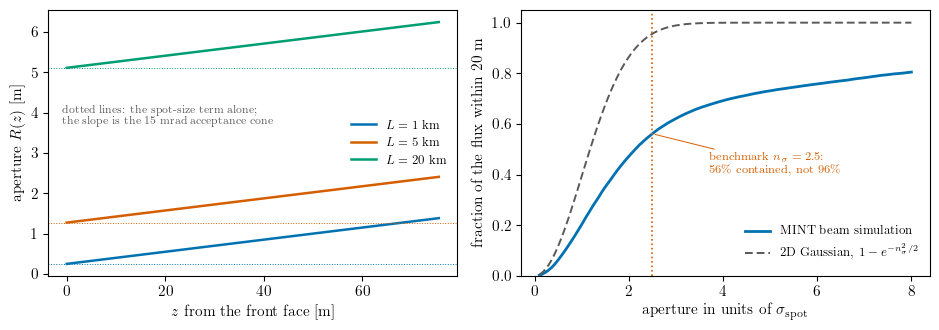

In [188]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))

z = np.linspace(0, det.Z_MUON1, 400)
for D, c, ls in [(1e5, "#0072B2", "-"), (5e5, "#D55E00", "-"), (20e5, "#009E73", "-")]:
    dd = mint.detectors.load("benchmark_5km", dist=D)
    ax[0].plot(z/100, dd.aperture(z)/100, color=c, ls=ls, lw=1.8,
               label=rf"$L = {D/1e5:.0f}$ km")
    ax[0].axhline(dd.n_sigma*dd.sigma_spot/100, color=c, lw=0.7, ls=":")
ax[0].set_xlabel(r"$z$ from the front face [m]")
ax[0].set_ylabel(r"aperture $R(z)$ [m]")
ax[0].legend(frameon=False, fontsize=9)
ax[0].annotate("dotted lines: the spot-size term alone;\n"
               "the slope is the 15 mrad acceptance cone",
               xy=(0.035, 0.60), xycoords="axes fraction", fontsize=8,
               color="0.35", va="center")

# measured containment vs the Gaussian the design assumes
ns_grid = np.linspace(0.1, 8.0, 120)
meas = np.array([w_all[r_face < n*det.sigma_spot].sum()/w_all.sum() for n in ns_grid])
ax[1].plot(ns_grid, meas, color="#0072B2", lw=2.0, label="MINT beam simulation")
ax[1].plot(ns_grid, 1-np.exp(-ns_grid**2/2), color="0.35", lw=1.4, ls=(0, (4, 2)),
           label=r"2D Gaussian, $1-e^{-n_\sigma^2/2}$")
ax[1].axvline(det.n_sigma, color="#D55E00", lw=1.2, ls=":")
ax[1].annotate(rf"benchmark $n_\sigma = {det.n_sigma}$:" "\n"
               rf"{frac*100:.0f}\% contained, not 96\%",
               xy=(det.n_sigma, frac), xytext=(0.46, 0.42),
               textcoords="axes fraction", fontsize=8.5, color="#D55E00",
               ha="left", va="center", clip_on=False,
               arrowprops=dict(arrowstyle="-", lw=0.7, color="#D55E00"))
ax[1].set_xlabel(r"aperture in units of $\sigma_{\rm spot}$")
ax[1].set_ylabel(rf"fraction of the flux within {R_MAX/100:.0f} m")
ax[1].set_ylim(0, 1.05)
ax[1].legend(frameon=False, fontsize=9, loc="lower right",
             bbox_to_anchor=(1.0, 0.02))
fig.tight_layout()
fig.savefig("../plots/benchmark_detector_aperture.pdf", bbox_inches="tight", dpi=300)

### The aperture does not contain 96% of the flux

The design sizes the aperture as $n_\sigma = 2.5$ of a **Gaussian** spot and
quotes 96% containment. The simulated beam does not behave that way, and the
discrepancy is not small:

* the **core is 1.7$\times$ wider** than the design spot -- the radius holding
  39.3% of the flux is 0.85 m against $\sigma_{\rm spot} = 0.51$ m, implying
  $\sigma_{\rm div} \simeq 0.17$ mrad rather than 0.10 mrad;
* the **tail is far heavier than Gaussian**. A Gaussian reaches 95.6% at
  2.5$\sigma$; the simulated flux needs $\sim$22$\sigma$. 90% of the flux
  within 20 m of the axis sits inside 7.4 m, not 1.3 m.

The cause is physics, not a bug: neutrinos from muon decay are not Gaussian in
angle. The lab-frame distribution has a $1/\gamma$ core sitting on a power-law
tail, and muons decay all the way around the ring rather than only along the
straight, so the flux crossing the face plane has no natural edge.

That last point makes "fraction contained" denominator-dependent, so the table
above scans it. There is no plateau: the fraction slides from 67% (counting only
flux within 5 m) to 14% (counting every ray that crosses the plane). **The
robust statement is that the benchmark aperture collects
$3.6\times10^{10}\,\nu$/yr, roughly half to two-thirds of the forward flux --
not 96% of it.**

This does not invalidate the geometry. It means the 96% should not be quoted in
the paper, and that widening the aperture buys more than the design assumes:
going from 2.5$\sigma$ to 5$\sigma$ (2.6 m) is a real gain, where for a
Gaussian it would be worth nothing.

## 2. Layout and composition

The stack, with $z$ measured from the front face:

| $z$ [m] | module | half-width | material |
|---|---|---|---|
| 0.0 | halo tagger | fixed 2 m | 0.4 g/cm$^2$ tracking, full face |
| 2.0 – 3.2 | **vertex tracker** | $\min(R,\,0.5\ {\rm m})$ | 24 plates (2 mm graphite + 150 $\mu$m Si) on a 5 cm pitch |
| 3.2 – 12.0 | drift | $R(z)$ | air (lever arm) |
| 12.0 – 51.5 | TPC core | $R(z)$ | 4 $\times$ 9.5 m of 5 bar argon, 0.5 m gaps |
| (in the gaps) | vessel walls | $R(z)$ | 0.20 $X_0$ carbon composite each |
| 52.0 | end cap | $R(z)$ | 0.30 $X_0$ carbon composite |
| 52.5 – 55.5 | calorimeter | $\max(R,3\,{\rm m})$ | 32 $X_0$ W/Si + 10 $\lambda_I$ Fe/scint |
| 55.5 – 75.5 | muon spectrometer | $\max(R,3\,{\rm m})$ | air-core dipole |

**The vertex tracker exists for charm, and nothing else.** $D^0$ and $D^\pm$
have $\gamma c\tau$ of order 1–15 cm over this energy range, so resolving their
decay needs a few-cm sampling pitch and a small impact parameter. It does *not*
need target mass -- the 38 m of gas supplies that far more cheaply -- so the
slab is kept thin (11 g/cm$^2$, 0.29 $X_0$) and, more importantly, **narrow**.

Silicon area is the cost driver. Instrumenting the full acceptance cone with 24
planes would take of order $10^3$ m$^2$, more than any tracker ever built;
capping the half-width at 0.5 m brings that to $\sim$19 m$^2$. The flux is
enormous, so a tracker that sees only the beam core still collects a large charm
sample, and every other process is left to the gas.

It is modelled as **one homogenised slab** -- the graphite plates and their
silicon sensors smeared over the plate pitch -- rather than 24 discrete
cassettes. That reproduces the column, $X_0$ and $\lambda_I$ exactly and places
interaction vertices uniformly along $z$, which is all a rate calculation can
use. It also cuts the detector from $\sim$212 ray-traced volumes to 13.

**Why graphite and not tungsten.** At a fixed radiation-length budget graphite
gives 21.4 g/cm$^2$ of target against tungsten's 3.4 -- a factor 6.3 in mass --
while tungsten buys only $\sim$1.6$\times$ in electromagnetically-coherent
yield, because the mass penalty nearly cancels the $Z^2/A$ gain. High-$Z$ is not
the automatic choice. (That comparison is specific to a mediator coupling to the
electromagnetic current; a $B-L$ or baryonic mediator scales as $A^2$, and an
incoherent process as $A$.) Override ``foil_mat`` to compare.

In [189]:
rows = det.column_table()
print(f"{'group':20s}{'z0 [m]':>8s}{'z1 [m]':>8s}{'material':>10s}"
      f"{'column':>11s}{'X0':>9s}{'lambda_I':>10s}")
print(f"{'':20s}{'':8s}{'':8s}{'[cm]':>10s}{'[g/cm2]':>11s}")
for r in rows:
    print(f"{r['group']:20s}{r['z0 [m]']:8.1f}{r['z1 [m]']:8.1f}"
          f"{r['material [cm]']:10.2f}{r['column [g/cm2]']:11.2f}"
          f"{r['X0']:9.3f}{r['lambda_I']:10.3f}")

trk = mint.detectors.TRACKING_KINDS
print(f"\ntracking region (everything upstream of the calorimeter):")
print(f"   column   = {det.column(kinds=trk):8.1f} g/cm^2")
print(f"   X0       = {det.radiation_lengths(kinds=trk):8.2f}")
print(f"   lambda_I = {det.interaction_lengths(kinds=trk):8.3f}")
print(f"   nucleons = {det.nucleon_column():.4e} /cm^2")
print(f"   electrons= {det.electron_column():.4e} /cm^2")

group                 z0 [m]  z1 [m]  material     column       X0  lambda_I
                                          [cm]    [g/cm2]
halo tagger              0.0    10.9      0.50       0.68    0.022     0.007
vertex tracker           2.0     3.2    120.00      11.45    0.287     0.131
TPC gas                 12.0    51.5   3800.00      31.58    1.615     0.269
TPC structure           21.7    52.0     17.39      38.43    0.900     0.448
calorimeter             52.5    55.3    277.20    1631.85  129.784    12.263
muon spectrometer       55.5    75.5   2000.00       2.45    0.067     0.027

tracking region (everything upstream of the calorimeter):
   column   =     82.1 g/cm^2
   X0       =     2.82
   lambda_I =    0.856
   nucleons = 2.5926e+25 /cm^2
   electrons= 1.2011e+25 /cm^2


### The layout figure

Materials are colour-coded; the palette is the Okabe-Ito colourblind-safe set,
checked for pairwise separation under deuteranopia, protanopia and tritanopia.
Air is left unfilled. Every region is also directly labelled, so identity is
never carried by colour alone.

NOTE: elements thinner than 40 cm are drawn at that width so they stay visible on a 75 m axis -- the halo monitor (0.38 cm), the TPC vessel walls (3.9 cm) and the end cap (5.8 cm). Their z positions, and every column density in this notebook, are exact.


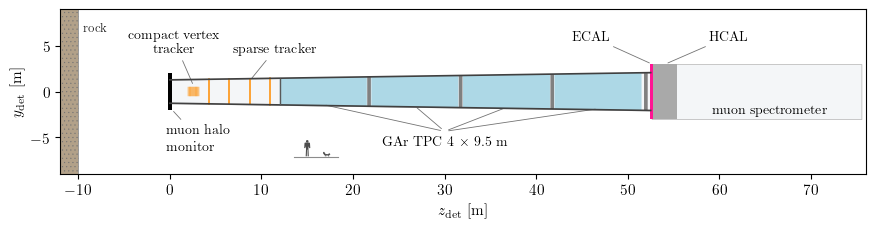

In [196]:
# Material -> (colour, label).
MAT_STYLE = [
    (det.gas,        "lightblue", r"5 bar Ar (TPC gas)"),
    (det.vertex_mat, "darkorange",    r"vertex tracker (graphite + Si)"),
    (det.vessel_mat, "grey",    r"graphite (TPC vessel walls)"),
    (det.halo_mat,   "black",      r"halo monitor"),
    (det.ecal_mat,   "deeppink",    r"W/Si (ECAL)"),
    (det.hcal_mat,   "darkgrey",    r"Fe/scint (HCAL)"),
]
COLOR = {id(m): c for m, c, _ in MAT_STYLE}
ENVELOPE = "#f4f6f8"
MIN_DRAW_CM = 40.0       # thin planes get widened to stay visible on a 75 m axis


def draw_stack(ax, dd, z_lo, z_hi, envelope=True):
    # Detector cross-section in (z, +/-r), both halves, metres.
    if envelope:
        zz = np.linspace(z_lo, z_hi, 400)
        rr = np.array([max(dd.aperture(z), dd.CALO_R_FLOOR)
                       if z >= dd.Z_CALO0 else dd.aperture(z) for z in zz])
        ax.fill_between(zz/100, -rr/100, rr/100, color=ENVELOPE,
                        edgecolor="0.75", lw=0.6, zorder=1)
    for m in dd.modules:
        if m.z1 < z_lo or m.z0 > z_hi or m.kind == "air":
            continue
        if m.name == "vertex tracker" or m.name.startswith("sparse"):
            continue          # drawn plane-by-plane below
        for (a, b, r0, r1) in dd._segments(m):
            if b - a < MIN_DRAW_CM:          # widen about the centre, keep z
                c = 0.5*(a + b)
                a, b = c - MIN_DRAW_CM/2, c + MIN_DRAW_CM/2
            xy = np.array([[a/100, r0/100], [b/100, r1/100],
                           [b/100, -r1/100], [a/100, -r0/100]])
            ax.add_patch(Polygon(xy, closed=True, facecolor=COLOR[id(m.material)],
                                 edgecolor="none", zorder=3))
    zz = np.linspace(z_lo, 5250, 300)
    for sgn in (+1, -1):
        ax.plot(zz/100, sgn*dd.aperture(zz)/100, color="0.25", lw=1.2, ls="-",
                zorder=5)


fig, ax = plt.subplots(figsize=(10.4, 3.9))
draw_stack(ax, det, 0.0, det.Z_MUON1)

ax.set_xlim(-det.gap / 100.0 - 2.0, 76)   # left edge = start of the rock
ax.set_ylim(-9, 9)
ax.set_xlabel(r"$z_{\rm det}$ [m]")
ax.set_ylabel(r"$y_{\rm det}$ [m]")

# ---------------------------------------------------------------------------
# upstream context: the last 2 m of the rock, then the air gap to the face
# ---------------------------------------------------------------------------
from matplotlib.patches import Rectangle, Circle, Ellipse

ROCK_C, Y_LIM = "#b2a189", 20.0        # taller than any ylim; axes clip it
z_rock1 = -det.gap / 100.0                    # rock ends where the gap starts
z_rock0 = z_rock1 - 2.0                       # show 2 m of it
ax.add_patch(Rectangle((z_rock0, -Y_LIM), 2.0, 2 * Y_LIM, facecolor=ROCK_C,
                       edgecolor="none", zorder=2))
ax.add_patch(Rectangle((z_rock0, -Y_LIM), 2.0, 2 * Y_LIM, facecolor="none",
                       edgecolor="0.45", lw=0.5, hatch="....", zorder=2))
ax.annotate("rock", xy=(z_rock1 + 0.5, 6.9), fontsize=9, color="0.15",
            ha="left", va="center")


# ---------------------------------------------------------------------------
# scale figures, drawn at true size on the equal-aspect axes
# ---------------------------------------------------------------------------
def draw_person(ax, x, y_feet, h=1.8, color="0.30", zorder=7):
    """A 1.8 m standing silhouette; coordinates are fractions of the height."""
    body = np.array([
        (-0.09, 0.855), (-0.165, 0.83), (-0.185, 0.52), (-0.125, 0.505),
        (-0.075, 0.625), (-0.075, 0.45), (-0.095, 0.015), (-0.025, 0.015),
        (-0.012, 0.42), (0.012, 0.42), (0.025, 0.015), (0.095, 0.015),
        (0.075, 0.45), (0.075, 0.625), (0.125, 0.505), (0.185, 0.52),
        (0.165, 0.83), (0.09, 0.855)])
    ax.add_patch(Polygon(np.column_stack([x + body[:, 0] * h,
                                          y_feet + body[:, 1] * h]),
                         closed=True, facecolor=color, edgecolor="none",
                         zorder=zorder))
    ax.add_patch(Circle((x, y_feet + 0.925 * h), 0.078 * h, facecolor=color,
                        edgecolor="none", zorder=zorder))


# Side-view cat as ONE closed outline: body, head, ears and all four legs are
# a single path, so nothing detaches and no notches open up when it is drawn
# only a few pixels tall. Coordinates are (length, height) fractions, nose
# first. (The previous version drew separate ellipses and rectangles, which at
# this scale read as two blobs rather than a cat.)
_CAT_OUTLINE = [
    (0.00, 0.60), (0.03, 0.71), (0.06, 0.76),          # nose, forehead
    (0.07, 1.00), (0.13, 0.80),                        # near ear
    (0.19, 0.81), (0.25, 0.99), (0.28, 0.78),          # far ear
    (0.32, 0.71), (0.39, 0.65),                        # back of head, neck
    (0.55, 0.67), (0.75, 0.69), (0.88, 0.65),          # back
    (0.96, 0.55), (0.98, 0.40), (0.94, 0.29),          # rump, haunch
    (0.95, 0.00), (0.89, 0.00), (0.90, 0.27),          # hind leg, far
    (0.80, 0.29), (0.79, 0.00), (0.73, 0.00),          # hind leg, near
    (0.74, 0.29), (0.41, 0.29),                        # belly
    (0.40, 0.00), (0.34, 0.00), (0.35, 0.29),          # fore leg, far
    (0.28, 0.29), (0.27, 0.00), (0.21, 0.00),          # fore leg, near
    (0.22, 0.33), (0.14, 0.41), (0.05, 0.51),          # chest, chin
]


def draw_cat(ax, x, y_feet, h=0.30, color="0.30", zorder=7, facing=-1, lw=1.2):
    """A cat in side view, ``h`` tall to the ear tips and 1.55 h long.
    ``facing`` = -1 puts the nose to the left, +1 to the right."""
    L = 1.55 * h

    def P(u, v):
        return (x + (u if facing > 0 else (1.0 - u)) * L, y_feet + v * h)

    ax.add_patch(Polygon([P(u, v) for u, v in _CAT_OUTLINE], closed=True,
                         facecolor=color, edgecolor="none", zorder=zorder))
    s = np.linspace(0.0, 1.0, 50)                       # tail, off the rump
    ax.plot(*zip(*[P(0.94 + 0.20 * np.sin(1.7 * t), 0.55 + 0.52 * t ** 0.8)
                   for t in s]),
            color=color, lw=lw, solid_capstyle="round", zorder=zorder)


# the two tracker stations, drawn as their individual planes
VTX_C, SPARSE_C = COLOR[id(det.vertex_mat)], "darkorange"
r_vtx = det.vertex_radius / 100.0
# NOTE 24 planes on a 5 cm pitch span 1.2 m, which on an 88 m frame is a
# 0.42 pt gap between them -- thinner than any sensible line. They are
# drawn as 24 separate strokes and resolve when the vector PDF is zoomed,
# but at normal size they necessarily merge into a bar. That is what a
# 5 cm-pitch stack actually looks like at this scale.
for z in np.linspace(det.Z_VTX0, det.Z_VTX1, det.n_plates, endpoint=False):
    ax.plot([z / 100.0] * 2, [-r_vtx, r_vtx], color=VTX_C, lw=0.28, zorder=4)
for m in det.modules:
    if not m.name.startswith("sparse"):
        continue
    zc = 0.5 * (m.z0 + m.z1)
    rr = det.aperture(zc) / 100.0
    ax.plot([zc / 100.0] * 2, [-rr, rr], color=SPARSE_C, lw=1.1, zorder=4)

Y_FLOOR = -7.1                                 # empty band below the TPC
draw_person(ax, 15.0, Y_FLOOR)
draw_cat(ax, 16.9, Y_FLOOR, h=0.40)   # ~0.4 m to the ear tips
ax.plot([13.6, 18.4], [Y_FLOOR, Y_FLOOR], color="0.55", lw=0.8, zorder=6)
# ax.annotate("", xy=(13.2, Y_FLOOR), xytext=(13.2, Y_FLOOR + 1.8),
            # arrowprops=dict(arrowstyle="<->", lw=0.7, color="0.45"))
# ax.annotate("1.8 m", xy=(12.9, Y_FLOOR + 0.9), fontsize=8, color="0.35",
            # ha="right", va="center")

LAB = [(r"\noindent muon halo\\ monitor",      3.0, -5.0,  0.2, -1.95, "center"),
       ("compact vertex\ntracker",             0.5,  5.4,  2.6,  0.60, "center"),
       ("sparse tracker",                     11.5,  4.6,  8.7,  1.15, "center"),
       ("ECAL",                               46.0,  6.0, 52.63, 3.00, "center"),
       ("HCAL",                               61.0,  6.0, 54.10, 3.00, "center"),
       ]
for text, xt, yt, xa, ya, ha in LAB:
    ax.annotate(text, xy=(xa, ya), xytext=(xt, yt), fontsize=10, color='black',
                ha=ha, va="center",
                arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45",
                                shrinkA=2, shrinkB=2))

# one label for the four gas modules, with the leaders fanning out of a single
# point so it is clear the caption covers all of them
fan = (30.0, -4.35)
for za, zb in det._tpc_module_edges():
    zc = 0.5 * (za + zb) / 100
    ax.annotate("", xy=(zc, -det.aperture(zc*100)/100 + 0.10), xytext=fan,
                arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45",
                                shrinkA=3, shrinkB=2))
ax.text(fan[0], -5.5, r"GAr TPC 4 $\times$ 9.5 m", fontsize=10, color="black",
        ha="center", va="center")

ax.annotate("muon spectrometer", xy=(65.5, -2.5), xytext=(65.5, -2), fontsize=10,
            color='black', ha="center", va="center")

# boundary between the upstream tracking region and the gas TPC
z_div = det.Z_TPC0 / 100
r_div = det.aperture(det.Z_TPC0) / 100
ax.plot([z_div, z_div], [-r_div, r_div], color="0.35", lw=1.0, ls=(0, (3, 0)),
        zorder=6)
# ax.annotate("tracker", xy=(z_div - 0.7, 2.35), fontsize=9, color="0.35",
#             ha="right", va="center")
# ax.annotate("gas TPC", xy=(z_div + 0.7, 2.35), fontsize=9, color="0.35",
#             ha="left", va="center")

ax.set_aspect("equal", adjustable="box")
handles = [Patch(facecolor=c, edgecolor="none", label=lab)
           for m, c, lab in MAT_STYLE]
handles += [Patch(facecolor=ENVELOPE, edgecolor="0.75", lw=0.6,
                  label="instrumented aperture (air)"),
            Line2D([0], [0], color="0.25", lw=1.2, label=r"aperture $R(z)$")]
fig.savefig("plots/benchmark_detector_layout.png", bbox_inches="tight", dpi=500)

print(f"NOTE: elements thinner than {MIN_DRAW_CM:.0f} cm are drawn at that width so "
      "they stay visible on a 75 m axis -- the halo monitor (0.38 cm), the TPC "
      "vessel walls (3.9 cm) and the end cap (5.8 cm). Their z positions, and "
      "every column density in this notebook, are exact.")


## 3. Material budget along the axis

Where the material actually sits. Column density and radiation/interaction
lengths are plotted in **separate panels** rather than on twin axes -- they are
different quantities and a shared frame with two scales would invite reading a
crossing point that means nothing.

The step at $z = 52.5$ m is the whole point of the redesign: the tracking region
carries 95 g/cm$^2$ and 1.5 $X_0$, and everything heavy is behind it.

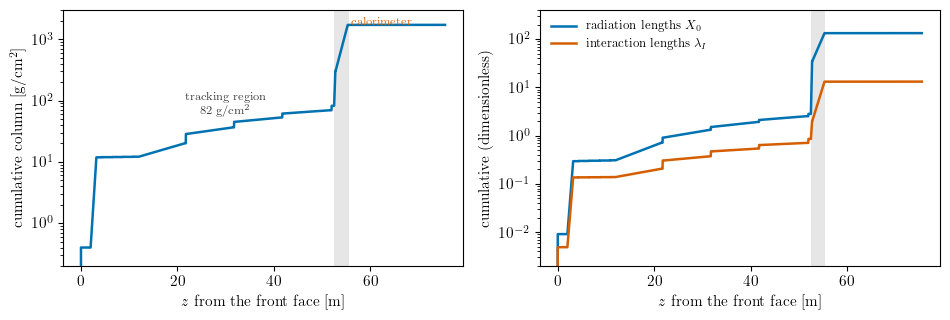

In [8]:
def cumulative(dd, kinds=None, quantity="column"):
    # cumulative material along the axis, as a step function of z
    edges, vals = [0.0], [0.0]
    mods = sorted([m for m in dd.modules
                   if kinds is None or m.kind in kinds], key=lambda m: m.z0)
    acc = 0.0
    for m in mods:
        if quantity == "column":
            step = m.material.density * m.thickness
        elif quantity == "X0":
            step = m.material.density * m.thickness / dt.radiation_length(m.material)
        else:
            step = m.material.density * m.thickness / dt.interaction_length(m.material)
        edges += [m.z0, m.z1]
        vals += [acc, acc + step]
        acc += step
    edges += [dd.Z_MUON1]
    vals += [acc]
    return np.array(edges)/100, np.array(vals)

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.3))

zc, cc = cumulative(det, quantity="column")
ax[0].plot(zc, cc, color="#0072B2", lw=1.8)
ax[0].set_yscale("log")
ax[0].set_ylim(0.2, 3e3)
ax[0].set_xlabel(r"$z$ from the front face [m]")
ax[0].set_ylabel(r"cumulative column [g/cm$^2$]")
ax[0].annotate(f"tracking region\n{det.column(kinds=trk):.0f} g/cm$^2$",
               xy=(30, 60), fontsize=8.5, color="0.25", ha="center")
ax[0].annotate("calorimeter", xy=(56, 1700), fontsize=8.5, color="#D55E00", ha="left")

for q, c, lab in [("X0", "#0072B2", r"radiation lengths $X_0$"),
                  ("lambda", "#D55E00", r"interaction lengths $\lambda_I$")]:
    zc, cc = cumulative(det, quantity=q)
    ax[1].plot(zc, cc, color=c, lw=1.8, label=lab)
ax[1].set_yscale("log")
ax[1].set_ylim(2e-3, 4e2)
ax[1].set_xlabel(r"$z$ from the front face [m]")
ax[1].set_ylabel("cumulative (dimensionless)")
ax[1].legend(frameon=False, fontsize=9, loc="upper left")
for a in ax:
    a.axvspan(52.5, 55.5, color="0.9", zorder=0, lw=0)
fig.tight_layout()
fig.savefig("../plots/benchmark_detector_budget.pdf", bbox_inches="tight", dpi=300)

## 4. What this changes for the rates

The comparison that matters for MINT: the new detector is much *lighter* but has
a much *longer* gas volume, so interaction rates go down while the decay volume
for long-lived states goes up.

In [9]:
old = mint.detectors.load("hpgar_5km")
old_col = old.gas.density*old.length + dt.W.density*old.target_thick_total

print(f"{'':32s}{'legacy hpgar_5km':>20s}{'benchmark_5km':>18s}{'ratio':>9s}")
def row(lab, a, b, fmt="{:.4g}"):
    print(f"{lab:32s}{fmt.format(a):>20s}{fmt.format(b):>18s}{b/a:>9.2f}")
row("tracking column [g/cm2]", old_col, det.column(kinds=trk))
row("tracking nucleons [1/cm2]", old.nucleon_column, det.nucleon_column())
row("tungsten in the tracker [g/cm2]", dt.W.density*old.target_thick_total, 0.0)
row("active gas length [m]", old.length/100, det.fiducial_length/100)
row("gas nucleon column [1/cm2]", old.gas.N*old.length, det.gas.N*det.fiducial_length)
row("front-face radius [m]", old.radius/100, det.radius/100)
row("face area [m2]", np.pi*(old.radius/100)**2, np.pi*(det.radius/100)**2)

print(f"\nvertex tracker: {det.n_plates} plates on a {det.plate_pitch:.0f} cm pitch, "
      f"r < {det.vertex_radius/100:.2f} m")
print(f"   silicon area  = {det.silicon_area:.1f} m2  (the whole acceptance cone "
      f"would need {det.n_plates*np.pi*(det.aperture(det.Z_VTX1)/100)**2:.0f} m2)")
print(f"   target column = {det.column(kinds=('vertex',)):.2f} g/cm2 in "
      f"{det.radiation_lengths(kinds=('vertex',)):.3f} X0")
print(f"   effective density = {det.vertex_mat.density:.4f} g/cm3")

# fiducial gas mass, from the exact frustum volumes
vols = det.fiducial_volumes()
mass = sum(v.volume_cm3()*det.gas.density for v in vols)/1e6
old_mass = np.pi*(old.radius**2)*old.length*old.gas.density/1e6
print(f"\nfiducial gas mass: {old_mass:.2f} t (legacy) -> {mass:.2f} t (benchmark)"
      f"   [{mass/old_mass:.2f}x]")

# ...and the same number by Monte Carlo, as a check on ConeVolume
rng = np.random.default_rng(1)
n = 2_000_000
zz = rng.uniform(det.dist + det.Z_TPC0, det.dist + det.Z_TPC1, n)
Rmax = det.aperture(det.Z_TPC1)
xx, yy = rng.uniform(-Rmax, Rmax, (2, n))
inside = np.zeros(n, bool)
for v in vols:
    inside |= v.contains(xx, yy, zz)
box = (2*Rmax)**2 * (det.Z_TPC1 - det.Z_TPC0)
print(f"MC cross-check of the gas volume: {inside.mean()*box*det.gas.density/1e6:.3f} t")

                                    legacy hpgar_5km     benchmark_5km    ratio
tracking column [g/cm2]                        305.9             82.13     0.27
tracking nucleons [1/cm2]                  1.844e+26         2.593e+25     0.14
tungsten in the tracker [g/cm2]                289.5                 0     0.00
active gas length [m]                             10                38     3.80
gas nucleon column [1/cm2]                 9.889e+24         1.904e+25     1.93
front-face radius [m]                              2             1.278     0.64
face area [m2]                                 12.57             5.128     0.41

vertex tracker: 24 plates on a 5 cm pitch, r < 0.50 m
   silicon area  = 18.8 m2  (the whole acceptance cone would need 132 m2)
   target column = 11.45 g/cm2 in 0.287 X0
   effective density = 0.0954 g/cm3

fiducial gas mass: 2.06 t (legacy) -> 3.08 t (benchmark)   [1.50x]
MC cross-check of the gas volume: 3.082 t


In [10]:
# neutrino interaction rate through the new geometry
E, w, chord = det.flux_with_chords(sim, exposure=ipy, kinds=("gas",))
sig = mint.xsecs.total_xsecs[sim.nuflavor](E)
n_gas = (w * sig * det.gas.N * chord).sum()
print(f"{sim.nuflavor} interactions in the TPC gas: {n_gas:.3e} / year")

E2, w2, ch2 = det.flux_with_chords(sim, exposure=ipy, kinds=("vertex",))
sig2 = mint.xsecs.total_xsecs[sim.nuflavor](E2)
print(f"{sim.nuflavor} interactions in the vertex tracker: "
      f"{(w2*sig2*det.vertex_mat.N*ch2).sum():.3e} / year")

# the whole-detector total has to be summed per volume, because each one
# carries its own nucleon density
rays = dt.sim_rays(sim)
E_all_r = np.asarray(sim.pnu["E"])
w_all_r = sim.weights.flatten() * ipy
sig_all = mint.xsecs.total_xsecs[sim.nuflavor](E_all_r)
tot = 0.0
for kinds, lab in [(("tracker",), "halo tagger"), (("vertex",), "vertex tracker"),
                   (("gas",), "argon gas"), (("structure",), "TPC vessel"),
                   (("absorber",), "calorimeter"),
                   (("air",), "spectrometer air")]:
    r = 0.0
    for v in det.volumes(kinds=kinds):
        _, c = v.intersect(*rays)
        r += float((w_all_r * sig_all * v.material.N * c).sum())
    tot += r
    print(f"   {lab:18s} {r:.3e} /yr")
print(f"   {'TOTAL':18s} {tot:.3e} /yr")

numubar interactions in the TPC gas: 3.595e+08 / year
numubar interactions in the vertex tracker: 4.014e+07 / year


   halo tagger        7.641e+06 /yr
   vertex tracker     4.014e+07 /yr


   argon gas          3.595e+08 /yr
   TPC vessel         4.451e+08 /yr


   calorimeter        2.135e+10 /yr
   spectrometer air   3.195e+07 /yr
   TOTAL              2.223e+10 /yr


## 5. Assumptions and caveats

**Stated in the design, implemented as given:** the aperture formula and its two
parameters; the module boundaries; the cassette segmentation (100 on a 10 cm
pitch); 5 bar argon over 38 m; the ECAL and HCAL layer recipes, which reproduce
32 $X_0$ and 10 $\lambda_I$ exactly.

**Assumed here, because the design gives a budget rather than a material:**

* The TPC pressure-vessel walls (0.20 $X_0$ each) and end cap (0.30 $X_0$) are
  taken to be **carbon composite**. The design specifies only the radiation
  length, but it also quotes 0.15 $\lambda_I$ for the end cap, and
  $\lambda_I/X_0$ for carbon reproduces that at 0.149 -- aluminium would give
  0.067. So carbon is what the numbers imply, not a free choice.
* The halo tagger's 0.4 g/cm$^2$ is modelled as plastic. Its column matches the
  design exactly, but its 0.009 $X_0$ falls short of the quoted 0.02, so the
  design's tagger must contain some silicon or support structure. Only the
  column enters a rate, so this does not propagate.
* The calorimeter is **homogenised** into two mixtures rather than 40 + 84
  discrete layers. MINT never resolves shower structure, and the mixture
  reproduces the column, $X_0$ and $\lambda_I$ exactly.

**Deliberately not implemented:** everything in the design's response sections --
resolutions, charge assignment, vertexing, conversion and pair separation,
calorimetric response, timing, occupancy. MINT counts rates. The swappable
cassette configurations are also not implemented; the single graphite option is
built in, and `foil_mat` can be overridden if a study needs the comparison.

**Note on the aperture.** `sigma_div` defaults to the design's 0.1 mrad. Section
1 measures what the beam simulation delivers; if the two disagree, the honest
move is to set `det.sigma_div = det.fit_sigma_div(sim)` and re-derive the
aperture rather than keep the design number.